In [1]:
library(Seurat)
library(qs)

Loading required package: SeuratObject

Loading required package: sp

‘SeuratObject’ was built with package ‘Matrix’ 1.7.0 but the current
version is 1.7.2; it is recomended that you reinstall ‘SeuratObject’ as
the ABI for ‘Matrix’ may have changed


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


qs 0.27.2. Announcement: https://github.com/qsbase/qs/issues/103



In [10]:
p3f_dosages_2wks <- readRDS("./in/seurat_obj/p3f_dosages_2wks.rds")
p3f_removal_postqc <- readRDS("./in/seurat_obj/p3f_removal_postqc.rds")
p3f_removal_singleR_ann <- readRDS("./in/seurat_obj/p3f_removal_singleR_ann.rds")

In [14]:
p3f_dosages_2wks
p3f_removal_postqc
p3f_removal_singleR_ann

An object of class Seurat 
20080 features across 24501 samples within 1 assay 
Active assay: RNA (20080 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

An object of class Seurat 
23016 features across 36919 samples within 1 assay 
Active assay: RNA (23016 features, 0 variable features)
 3 layers present: counts.SEG0503, counts.SEG0504, counts.SEG0505

An object of class Seurat 
23016 features across 36919 samples within 1 assay 
Active assay: RNA (23016 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: pca, umap, harmony

In [3]:
head(p3f_dosages_2wks@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,condition,log10GenesPerUMI,seurat_clusters,S.Score,G2M.Score,Phase,⋯,Idents,Progenitor_Score1,Proliferative_Score2,Differentiated_Score3,muscle_lineage_score,RNA_snn_res.0.1,RNA_snn_res.0.2,RNA_snn_res.0.3,clusters,subclusters_2
,<chr>,<dbl>,<int>,<dbl>,<chr>,<dbl>,<fct>,<dbl>,<dbl>,<chr>,⋯,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<fct>,<fct>,<fct>
AAACCCAAGGTAGCAC-1_2_1_1,SeuratProject,8496,2488,1.494821,Dbt-0-2wk,0.8642568,0,-0.1304060,-0.2375770,G1,⋯,RNA_snn_res.0.4,0.2974981,-0.04866097,-0.0198814184,-0.3173795,1,0,0,1,Progenitor-like
AAACCCACAAGAGGTC-1_2_1_1,SeuratProject,11737,3298,2.760501,Dbt-0-2wk,0.8645291,0,-0.1310312,-0.3119863,G1,⋯,RNA_snn_res.0.4,0.3484848,-0.13707744,0.0003150633,-0.3481697,1,0,0,1,Progenitor-like
AAACCCACAATGAACA-1_2_1_1,SeuratProject,15256,3769,2.648138,Dbt-0-2wk,0.8548528,4,-0.1798180,-0.3561494,G1,⋯,RNA_snn_res.0.4,0.2612912,-0.16113789,0.1176787343,-0.1436124,2,3,4,2,Progenitor-like
AAACCCACACCTAAAC-1_2_1_1,SeuratProject,13171,4045,2.680131,Dbt-0-2wk,0.8755467,4,-0.1678906,-0.2465055,G1,⋯,RNA_snn_res.0.4,0.3408364,-0.01497863,0.0095202486,-0.3313161,2,3,4,2,Progenitor-like
AAACCCACATGCAGCC-1_2_1_1,SeuratProject,8244,2674,2.316836,Dbt-0-2wk,0.8751381,0,-0.1586131,-0.3081785,G1,⋯,RNA_snn_res.0.4,0.2269301,-0.14478705,-0.0271120688,-0.2540422,1,0,0,1,Progenitor-like
AAACCCAGTAACCAGG-1_2_1_1,SeuratProject,15032,3622,2.687600,Dbt-0-2wk,0.8520312,0,-0.1975545,-0.3292360,G1,⋯,RNA_snn_res.0.4,0.2958826,-0.13581644,-0.0041053470,-0.2999879,1,0,0,1,Progenitor-like


In [11]:
head(p3f_removal_postqc@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,log10GenesPerUMI
,<chr>,<dbl>,<int>,<dbl>,<dbl>
SEG503_AAACCCAAGAAGTCAT-1,SEG0503,5796,2458,4.658385,0.9010009
SEG503_AAACCCAAGGAATCGC-1,SEG0503,20641,5489,4.738143,0.8666806
SEG503_AAACCCAAGTAATTGG-1,SEG0503,21549,5680,5.387721,0.8663693
SEG503_AAACCCACAGCCCACA-1,SEG0503,17007,5421,3.780796,0.8826301
SEG503_AAACCCACATTCAGCA-1,SEG0503,23659,5672,5.334122,0.8581937
SEG503_AAACCCATCACTTGGA-1,SEG0503,24531,5758,3.094044,0.8566095


In [12]:
head(p3f_removal_singleR_ann@meta.data)

,orig.ident,nCount_RNA,nFeature_RNA,percent.mt,log10GenesPerUMI,S.Score,G2M.Score,Phase,RNA_snn_res.0.1,RNA_snn_res.0.2,⋯,RNA_snn_res.0.8,seurat_clusters,clusters,Cycling1,Progenitor-like1,Ground state2,AP-1 expressing3,Differentiated4,PAX3-FOXO1-specific5,SingleR.labels
,<chr>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<fct>,<fct>,⋯,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
SEG503_AAACCCAAGAAGTCAT-1,SEG0503,5796,2458,4.658385,0.9010009,0.15915266,0.13525410,S,0,1,⋯,9,9,0,0.2343717,-0.5864161,-0.12758098,0.01101596,0.01980931,0.3626274,Cycling
SEG503_AAACCCAAGGAATCGC-1,SEG0503,20641,5489,4.738143,0.8666806,0.10455204,-0.18610886,S,0,1,⋯,2,2,0,0.1383499,-0.5501381,-0.23233252,0.02746396,0.06853656,0.4227474,PAX3-FOXO1-specific
SEG503_AAACCCAAGTAATTGG-1,SEG0503,21549,5680,5.387721,0.8663693,0.07326734,0.05827505,S,0,1,⋯,9,9,0,0.1550306,-0.5028639,-0.24107637,0.03027185,0.01883113,0.4394084,Cycling
SEG503_AAACCCACAGCCCACA-1,SEG0503,17007,5421,3.780796,0.8826301,0.35113299,-0.07584839,S,0,1,⋯,9,9,0,0.1676824,-0.6266501,-0.16483036,0.03158106,0.06413406,0.3750516,PAX3-FOXO1-specific
SEG503_AAACCCACATTCAGCA-1,SEG0503,23659,5672,5.334122,0.8581937,0.40407499,-0.12167554,S,0,1,⋯,7,7,0,0.1997978,-0.3487828,-0.01874806,0.02426372,0.07351748,0.2768568,PAX3-FOXO1-specific
SEG503_AAACCCATCACTTGGA-1,SEG0503,24531,5758,3.094044,0.8566095,0.17503419,-0.02390098,S,0,1,⋯,7,7,0,0.1399948,-0.1954640,-0.07791295,-0.01048957,0.02965502,0.1052753,Cycling


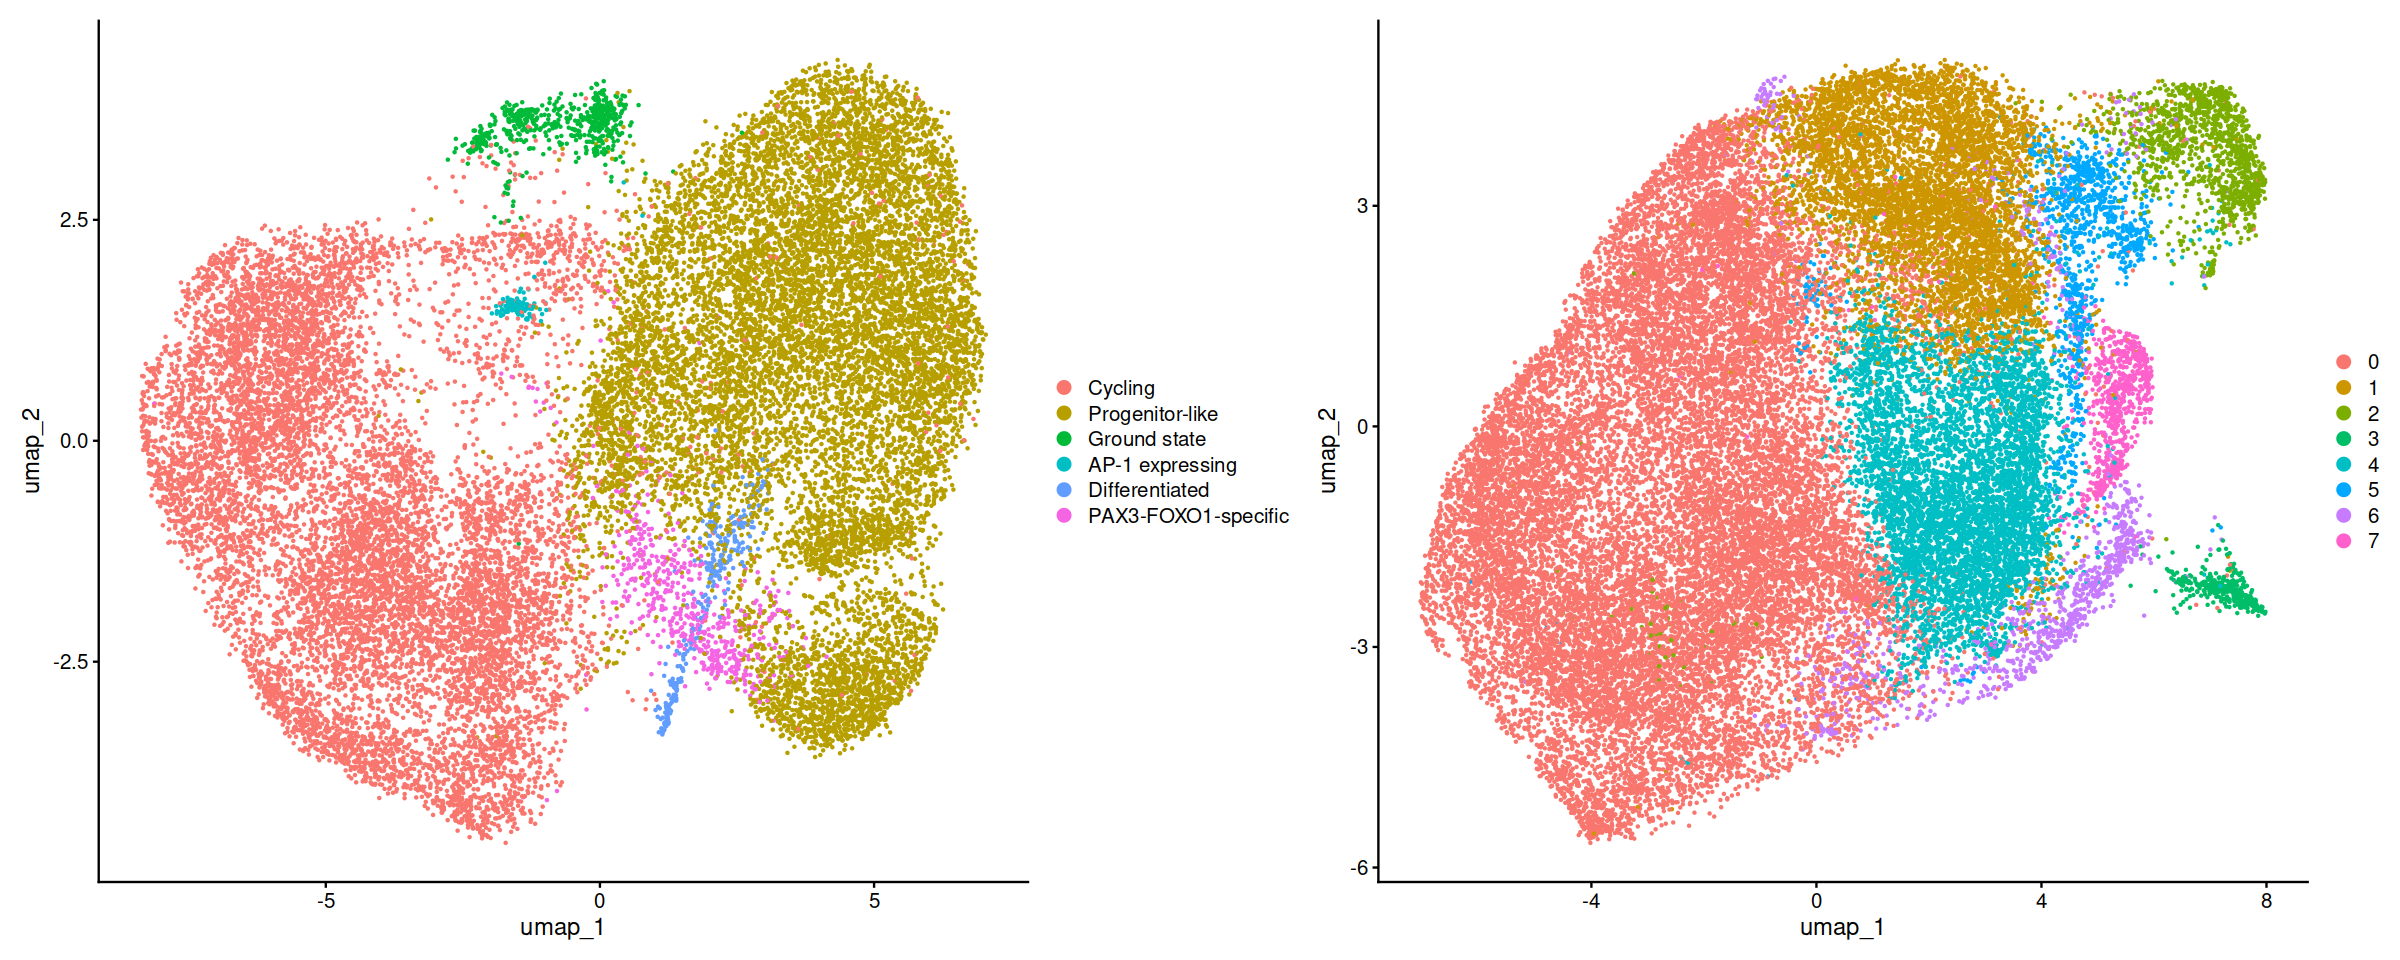

In [13]:
options(repr.plot.width=20, repr.plot.height=8)

p1 <- DimPlot(p3f_dosages_2wks)
p2 <- DimPlot(p3f_removal_singleR_ann)

p1 | p2